# Métodos de agrupamiento

## Algoritmos de agrupamiento jerárquicos

In [3]:
import pandas as pd
from google.colab import files

# Cargue y depuración del conjunto de datos
uploaded = files.upload()
datos = pd.read_excel("Trabajadores.xlsx")

datos.iloc[:, [0, 2, 7, 11]] = datos.iloc[:, [0, 2, 7, 11]].astype("category")

datos["Escolaridad"] = pd.Categorical(
    datos["Escolaridad"],
    categories=["Técnico", "Pregrado", "Posgrado"],
    ordered=True
)

datos["Estrato"] = datos["Estrato"].astype("string").str.strip().replace({
    "1.0": "1",
    "2.0": "2",
    "3.0": "3"
})

datos["Estrato"] = pd.Categorical(
    datos["Estrato"],
    categories=["1", "2", "3", "4+"],
    ordered=True
)

datos["Situación"] = pd.Categorical(
    datos["Situación"],
    categories=["Difícil", "Regular", "Buena"],
    ordered=True
)

print(datos.head())
print(datos.shape)

Saving Trabajadores.xlsx to Trabajadores.xlsx
  Sexo  Edad  Estado  Hijos Escolaridad Estrato  Ingresos Ayuda  Dependen  \
0    F    45  Casado      2    Posgrado      4+     8.800    No         3   
1    M    36  Casado      2    Pregrado       3     5.920    No         1   
2    M    61  Casado      3     Técnico       2     2.256    Sí         2   
3    F    40   Viudo      2    Posgrado       2     5.706    No         2   
4    F    49  Casado      3    Posgrado      4+     9.450    Sí         1   

   Egresos Situación      Créditos  Conocimiento  
0    8.410     Buena  Sin Créditos         0.249  
1    3.915     Buena      Vigentes         0.491  
2    2.390   Difícil      Vigentes         0.449  
3    3.480     Buena      Vigentes         0.506  
4    2.900     Buena      Vigentes         0.675  
(168, 13)


## Agrupamiento jerárquico

### Variables numéricas

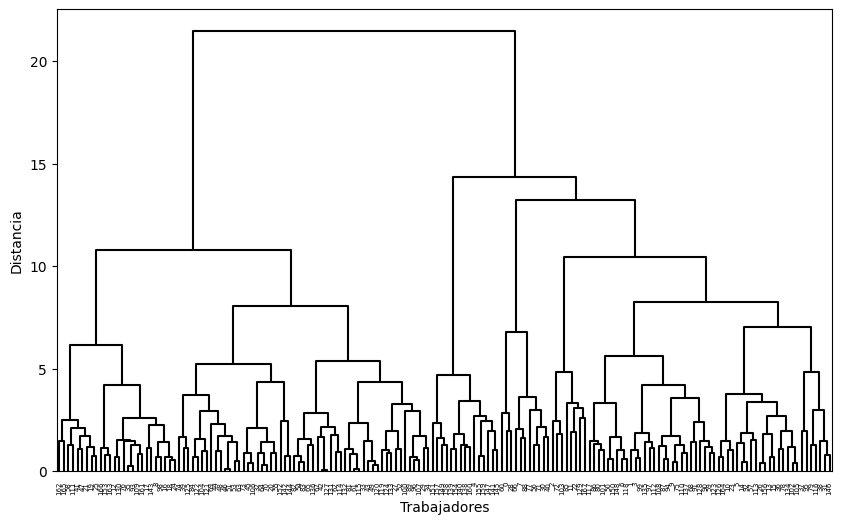

In [6]:
# Agrupamiento jerárquico

import matplotlib.pyplot as plt
from google.colab import files
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Variables numéricas

# Método de Ward
X = datos.select_dtypes(include="number")
X = (X - X.mean()) / X.std(ddof=1) # estandarización

ag_jer = linkage(X, method="ward", metric="euclidean") # función básica

# Dendrograma (función básica)
plt.figure(figsize=(10, 6))
dendrogram(
    ag_jer,
    labels=datos.index.astype(str),
    leaf_rotation=90,
    color_threshold=0,
    above_threshold_color="black"
)
plt.title("")
plt.xlabel("Trabajadores")
plt.ylabel("Distancia")
plt.show()

[2 2 2 2 2 2 2 2 1 2 2 2 1 2 2 2 1 1 1 1 1 1 2 2 1 1 2 1 2 1 2 2 1 1 1 1 2
 2 2 1 2 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 2 2 1 2 2 1 1 1 1 1 2 1 2 1 1 2 2 1
 1 2 1 2 2 2 2 1 1 1 1 2 2 2 2 1 2 2 2 1 2 2 1 2 1 2 1 2 2 2 1 2 1 1 2 1 2
 1 2 2 1 1 2 2 2 1 1 1 1 2 1 1 2 1 2 2 1 1 1 1 2 2 1 2 2 2 2 2 1 1 1 2 2 2
 2 2 2 2 1 1 2 2 2 2 2 2 2 1 1 1 2 1 1 2]


,grupos,Sexo,Edad,Estado,Hijos,Escolaridad,Estrato,Ingresos,Ayuda,Dependen,Egresos,Situación,Créditos,Conocimiento
0,2,F,45,Casado,2,Posgrado,4+,8.800,No,3,8.410,Buena,Sin Créditos,0.249
1,2,M,36,Casado,2,Pregrado,3,5.920,No,1,3.915,Buena,Vigentes,0.491
2,2,M,61,Casado,3,Técnico,2,2.256,Sí,2,2.390,Difícil,Vigentes,0.449
3,2,F,40,Viudo,2,Posgrado,2,5.706,No,2,3.480,Buena,Vigentes,0.506
4,2,F,49,Casado,3,Posgrado,4+,9.450,Sí,1,2.900,Buena,Vigentes,0.675
5,2,F,48,Separado,2,Pregrado,2,5.835,No,1,2.755,Regular,Vigentes,0.549
6,2,M,34,Casado,2,Pregrado,3,5.700,No,3,3.770,Regular,Vigentes,0.449
7,2,F,49,Unión Libre,2,Posgrado,3,6.246,No,3,4.250,Buena,En Mora,0.670
8,1,M,29,Soltero,0,Posgrado,3,4.500,No,3,3.190,Buena,Vigentes,0.395
9,2,F,39,Unión Libre,1,Pregrado,3,4.650,No,3,2.610,Regular,En Mora,0.549


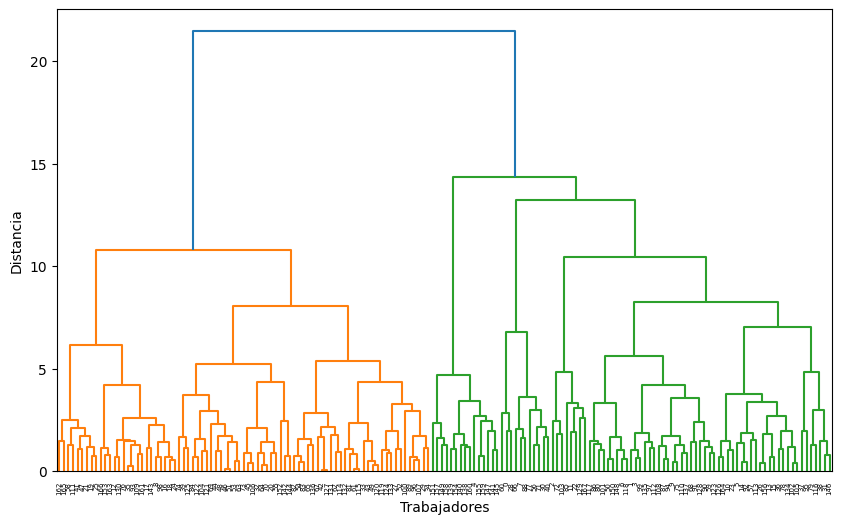

In [7]:
# Agrupamiento (función mejorada)
# Asignación de los trabajadores a k grupos
k = 2 # número de grupos (se debe determinar)

ag_jer = linkage(X, method="ward", metric="euclidean")

# Asignación de los trabajadores a los grupos
grupos = fcluster(
    ag_jer,
    t=k,
    criterion="maxclust"
)

print(grupos)
display(pd.concat([pd.DataFrame({"grupos": grupos}, index=datos.index), datos], axis=1).head(10))

# Dendrograma con la partición en k grupos
altura_corte = (ag_jer[-k, 2] + ag_jer[-(k - 1), 2]) / 2

plt.figure(figsize=(10, 6))
dendrogram(
    ag_jer,
    labels=datos.index.astype(str),
    leaf_rotation=90,
    color_threshold=altura_corte
)
plt.title("")
plt.xlabel("Trabajadores")
plt.ylabel("Distancia")
plt.show()

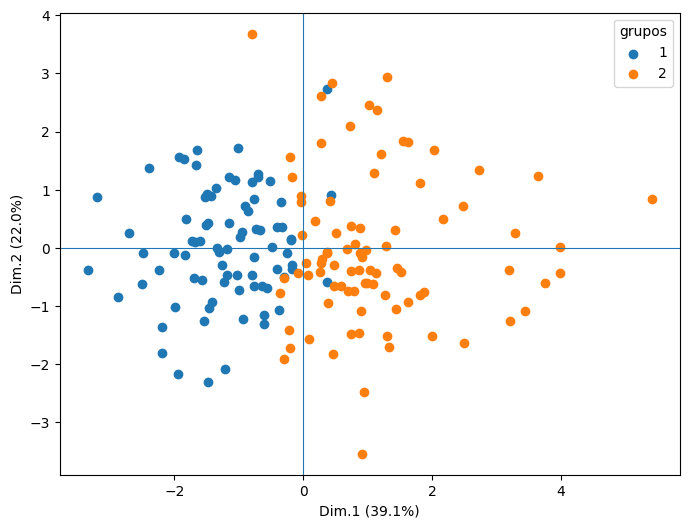

In [8]:
from sklearn.decomposition import PCA

# Representación de los grupos en un ACP
X = datos.select_dtypes(include="number")
X = (X - X.mean()) / X.std(ddof=1)

acp = PCA(n_components=2)
coord = acp.fit_transform(X)

acp_grupos = pd.DataFrame(
    coord,
    columns=["Dim.1", "Dim.2"],
    index=datos.index
)

acp_grupos["grupos"] = grupos.astype(str)

plt.figure(figsize=(8, 6))
for g in sorted(acp_grupos["grupos"].unique()):
    temp = acp_grupos[acp_grupos["grupos"] == g]
    plt.scatter(temp["Dim.1"], temp["Dim.2"], label=g)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel(f"Dim.1 ({acp.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"Dim.2 ({acp.explained_variance_ratio_[1] * 100:.1f}%)")
plt.legend(title="grupos")
plt.show()

## Validación

In [12]:
# Validación

import numpy as np
from sklearn.metrics import pairwise_distances, silhouette_score

# Distancia
X = datos.select_dtypes(include="number")
X = (X - X.mean()) / X.std(ddof=1)

D = pairwise_distances(X, metric="euclidean")
np.fill_diagonal(D, 0)

# Validación interna
val = silhouette_score(D, grupos, metric="precomputed")

val # Silhouette promedio

np.float64(0.20329934446777667)

In [13]:
# Dunn
clusters = np.unique(grupos)

diametros = []
separaciones = []

for g in clusters:
    idx = grupos == g
    diametros.append(D[np.ix_(idx, idx)].max())

for i, g1 in enumerate(clusters):
    for g2 in clusters[(i + 1):]:
        idx1 = grupos == g1
        idx2 = grupos == g2
        separaciones.append(D[np.ix_(idx1, idx2)].min())

val = min(separaciones) / max(diametros)

val # Dunn

np.float64(0.08658456820381448)

In [14]:
from sklearn.metrics import calinski_harabasz_score

val = calinski_harabasz_score(X, grupos)

val # Calinski-Harabasz

np.float64(49.49295198390772)

In [15]:
from sklearn.metrics import davies_bouldin_score

val = davies_bouldin_score(X, grupos)

val # Davies-Bouldin

np.float64(1.6748552927250944)

In [16]:
# Connectivity
neighbSize = 10

D_aux = D.copy()
np.fill_diagonal(D_aux, np.inf)

vecinos = np.argsort(D_aux, axis=1)[:, :neighbSize]

val = 0

for i in range(D_aux.shape[0]):
    for j in range(neighbSize):
        if grupos[i] != grupos[vecinos[i, j]]:
            val += 1 / (j + 1)

val # Connectivity

39.403174603174655

In [17]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import pairwise_distances

np.random.seed(123)

val_gap = []

for kk in range(1, k + 1):
    ag_k = linkage(X, method="ward", metric="euclidean")
    grupos_k = fcluster(ag_k, t=kk, criterion="maxclust")

    Wk = 0

    for g in np.unique(grupos_k):
        idx = grupos_k == g
        if idx.sum() > 1:
            Dg = pairwise_distances(X.iloc[idx], metric="euclidean")
            Wk += Dg.sum() / (2 * idx.sum())

    Wkb = []

    for b in range(100):
        Xb = pd.DataFrame(
            np.random.uniform(
                low=X.min().to_numpy(),
                high=X.max().to_numpy(),
                size=X.shape
            ),
            columns=X.columns
        )

        ag_b = linkage(Xb, method="ward", metric="euclidean")
        grupos_b = fcluster(ag_b, t=kk, criterion="maxclust")

        Wb = 0

        for g in np.unique(grupos_b):
            idx = grupos_b == g
            if idx.sum() > 1:
                Db = pairwise_distances(Xb.iloc[idx], metric="euclidean")
                Wb += Db.sum() / (2 * idx.sum())

        Wkb.append(Wb)

    val_gap.append(np.mean(np.log(Wkb)) - np.log(Wk))

val = val_gap[k - 1]

val # Gap statistic

np.float64(0.46300109675184054)

In [18]:
# Medidas de estabilidad

# APN
apn_vals = []

for col in X.columns:
    X_menos = X.drop(columns=col)

    ag_menos = linkage(X_menos, method="ward", metric="euclidean")
    grupos_menos = fcluster(ag_menos, t=k, criterion="maxclust")

    apn_col = 0

    for i in range(X.shape[0]):
        grupo_original = np.where(grupos == grupos[i])[0]
        grupo_menos = np.where(grupos_menos == grupos_menos[i])[0]

        apn_col += 1 - len(np.intersect1d(grupo_original, grupo_menos)) / len(grupo_original)

    apn_vals.append(apn_col / X.shape[0])

val = np.mean(apn_vals)

val # APN

np.float64(0.20498253224945437)

In [19]:
# FOM
fom_vals = []

for col in X.columns:
    X_menos = X.drop(columns=col)

    ag_menos = linkage(X_menos, method="ward", metric="euclidean")
    grupos_menos = fcluster(ag_menos, t=k, criterion="maxclust")

    suma = 0

    for g in np.unique(grupos_menos):
        idx = grupos_menos == g
        xg = X.loc[idx, col]
        suma += ((xg - xg.mean()) ** 2).sum()

    fom_vals.append(np.sqrt(suma / X.shape[0]))

val = np.mean(fom_vals)

val # FOM

np.float64(0.9453500862879859)

In [20]:
# Prediction strength
np.random.seed(123)

pred_vals = []

for m in range(100):
    idx = np.random.permutation(X.shape[0])
    idx_1 = idx[:X.shape[0] // 2]
    idx_2 = idx[X.shape[0] // 2:]

    X_1 = X.iloc[idx_1]
    X_2 = X.iloc[idx_2]

    ag_1 = linkage(X_1, method="ward", metric="euclidean")
    grupos_1 = fcluster(ag_1, t=k, criterion="maxclust")

    ag_2 = linkage(X_2, method="ward", metric="euclidean")
    grupos_2 = fcluster(ag_2, t=k, criterion="maxclust")

    centroides = X_1.copy()
    centroides["grupo"] = grupos_1
    centroides = centroides.groupby("grupo").mean()

    dist_cent = pairwise_distances(X_2, centroides, metric="euclidean")
    grupos_pred = dist_cent.argmin(axis=1) + 1

    ps = []

    for g in np.unique(grupos_2):
        idx_g = np.where(grupos_2 == g)[0]

        if len(idx_g) > 1:
            total = 0
            coinciden = 0

            for i in range(len(idx_g)):
                for j in range(i + 1, len(idx_g)):
                    total += 1

                    if grupos_pred[idx_g[i]] == grupos_pred[idx_g[j]]:
                        coinciden += 1

            ps.append(coinciden / total)

    pred_vals.append(min(ps))

val = np.mean(pred_vals)

val # Prediction strength

np.float64(0.6559983231578314)

In [23]:
# Bootstrap Jaccard stability
np.random.seed(123)

B = 100
grupos_array = np.asarray(grupos)
clusters_original = np.unique(grupos_array)

original_clusters = {
    g: set(np.where(grupos_array == g)[0])
    for g in clusters_original
}

boot_jaccard = {
    g: []
    for g in clusters_original
}

for b in range(B):
    idx_boot = np.random.choice(X.shape[0], size=X.shape[0], replace=True)
    X_boot = X.iloc[idx_boot]

    ag_boot = linkage(X_boot, method="ward", metric="euclidean")
    grupos_boot = fcluster(ag_boot, t=k, criterion="maxclust")

    for g in clusters_original:
        original = original_clusters[g]
        jaccards = []

        for gb in np.unique(grupos_boot):
            boot_cluster = set(idx_boot[grupos_boot == gb])

            interseccion = len(original.intersection(boot_cluster))
            union = len(original.union(boot_cluster))

            jaccards.append(interseccion / union)

        boot_jaccard[g].append(max(jaccards))

bootmean = pd.Series(
    {
        g: np.mean(boot_jaccard[g])
        for g in clusters_original
    },
    name="Bootstrap Jaccard stability"
)

bootmean
bootmean.mean()

np.float64(0.4856265216758519)

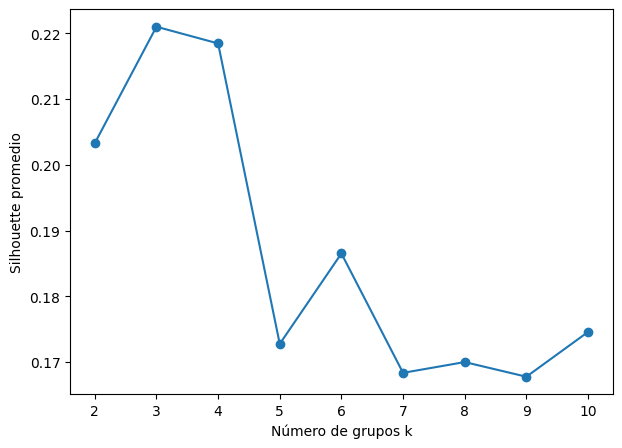

In [24]:
from sklearn.metrics import silhouette_samples

# Gráficas

# Silhouette o Gap
K_max = 10
val_sil = []

for kk in range(2, K_max + 1):
    ag_k = linkage(X, method="ward", metric="euclidean")
    grupos_k = fcluster(ag_k, t=kk, criterion="maxclust")

    val_sil.append(
        silhouette_score(D, grupos_k, metric="precomputed")
    )

plt.figure(figsize=(7, 5))
plt.plot(range(2, K_max + 1), val_sil, marker="o")
plt.xlabel("Número de grupos k")
plt.ylabel("Silhouette promedio")
plt.show()

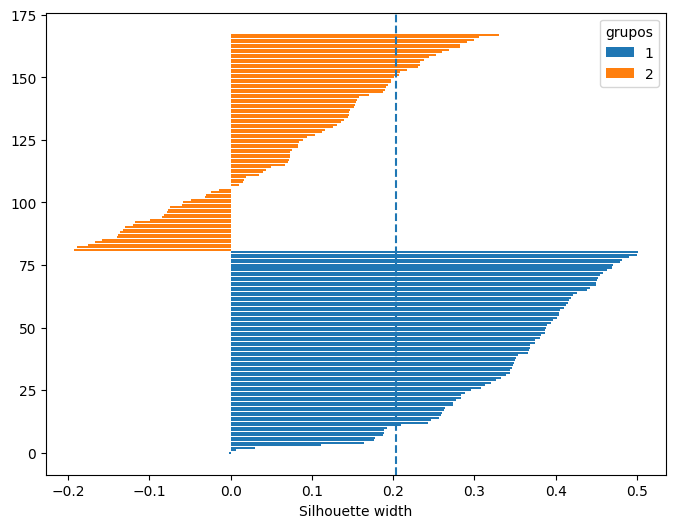

In [25]:
sil = silhouette_samples(D, grupos, metric="precomputed") # Silhouette por individuo

sil_df = pd.DataFrame({
    "sil_width": sil,
    "grupos": grupos
})

sil_df = sil_df.sort_values(["grupos", "sil_width"]).reset_index(drop=True)

plt.figure(figsize=(8, 6))

y_lower = 0

for g in sorted(sil_df["grupos"].unique()):
    vals = sil_df.loc[sil_df["grupos"] == g, "sil_width"].to_numpy()
    y_upper = y_lower + len(vals)

    plt.barh(
        range(y_lower, y_upper),
        vals,
        edgecolor="none",
        label=str(g)
    )

    y_lower = y_upper

plt.axvline(sil.mean(), linestyle="--")
plt.xlabel("Silhouette width")
plt.ylabel("")
plt.legend(title="grupos")
plt.show()

## Variables numéricas, binarias, categóricas y ordinales


In [28]:
# Variables numéricas, binarias, categóricas y ordinales

# Método de Ward
k = 3 # número de grupos

X = datos.copy()

X["Ayuda"] = np.where(X["Ayuda"] == "Sí", 1, 0) # binarias deben ser 0,1

numeric_vars = X.columns[[1, 3, 6, 8, 9, 12]].tolist()
asymm_vars = X.columns[[7]].tolist()
factor_vars = X.columns[[0, 2, 11]].tolist()
ordered_vars = X.columns[[4, 5, 10]].tolist()

X[factor_vars] = X[factor_vars].astype("category")

X[ordered_vars[0]] = pd.Categorical(
    X[ordered_vars[0]],
    categories=["Técnico", "Pregrado", "Posgrado"],
    ordered=True
)

X[ordered_vars[1]] = X[ordered_vars[1]].astype("string").str.strip().replace({
    "1.0": "1",
    "2.0": "2",
    "3.0": "3"
})

X[ordered_vars[1]] = pd.Categorical(
    X[ordered_vars[1]],
    categories=["1", "2", "3", "4+"],
    ordered=True
)

X[ordered_vars[2]] = pd.Categorical(
    X[ordered_vars[2]],
    categories=["Difícil", "Regular", "Buena"],
    ordered=True
)

partes = []
pesos = []

A = X[numeric_vars].astype(float)
A = (A - A.min()) / (A.max() - A.min())
A = A.to_numpy()

partes.append(np.abs(A[:, None, :] - A[None, :, :]))
pesos.append(np.ones_like(partes[-1]))

A = X[factor_vars].astype(str).to_numpy()

partes.append((A[:, None, :] != A[None, :, :]).astype(float))
pesos.append(np.ones_like(partes[-1]))

X_ord = pd.DataFrame(index=X.index)

X_ord[ordered_vars[0]] = X[ordered_vars[0]].cat.codes / 2
X_ord[ordered_vars[1]] = X[ordered_vars[1]].cat.codes / 3
X_ord[ordered_vars[2]] = X[ordered_vars[2]].cat.codes / 2

A = X_ord.to_numpy()

partes.append(np.abs(A[:, None, :] - A[None, :, :]))
pesos.append(np.ones_like(partes[-1]))

A = X[asymm_vars].to_numpy()

dist_asymm = (A[:, None, :] != A[None, :, :]).astype(float)
peso_asymm = ~((A[:, None, :] == 0) & (A[None, :, :] == 0))

partes.append(dist_asymm)
pesos.append(peso_asymm.astype(float))

num = np.concatenate(partes, axis=2)
w = np.concatenate(pesos, axis=2)

D = (num * w).sum(axis=2) / w.sum(axis=2)
np.fill_diagonal(D, 0)

D_cond = D[np.triu_indices(D.shape[0], k=1)]


In [29]:
ag_jer = linkage(D_cond, method="ward")

# Asignación de los trabajadores a los grupos
grupos = fcluster(
    ag_jer,
    t=k,
    criterion="maxclust"
)

print(grupos)
display(pd.concat([pd.DataFrame({"grupos": grupos}, index=datos.index), datos], axis=1).head(10))

[1 2 2 1 1 1 2 1 3 1 3 2 3 2 3 2 3 2 3 3 3 3 2 2 3 3 3 3 1 3 2 2 3 3 3 3 1
 3 1 2 2 3 1 3 2 3 1 3 1 3 2 1 2 1 2 3 1 1 3 2 2 3 3 2 3 2 1 3 1 3 3 2 2 3
 1 2 3 1 1 1 2 3 1 1 3 1 2 2 1 1 2 2 2 3 2 1 3 1 3 1 3 2 1 1 1 1 1 3 1 1 3
 3 2 1 3 3 1 1 2 2 3 1 1 1 2 1 2 1 2 2 2 2 1 1 2 2 2 1 1 2 1 2 3 2 3 1 2 1
 2 1 2 3 3 1 2 1 1 1 2 1 1 1 2 1 2 1 2 2]


,grupos,Sexo,Edad,Estado,Hijos,Escolaridad,Estrato,Ingresos,Ayuda,Dependen,Egresos,Situación,Créditos,Conocimiento
0,1,F,45,Casado,2,Posgrado,4+,8.800,No,3,8.410,Buena,Sin Créditos,0.249
1,2,M,36,Casado,2,Pregrado,3,5.920,No,1,3.915,Buena,Vigentes,0.491
2,2,M,61,Casado,3,Técnico,2,2.256,Sí,2,2.390,Difícil,Vigentes,0.449
3,1,F,40,Viudo,2,Posgrado,2,5.706,No,2,3.480,Buena,Vigentes,0.506
4,1,F,49,Casado,3,Posgrado,4+,9.450,Sí,1,2.900,Buena,Vigentes,0.675
5,1,F,48,Separado,2,Pregrado,2,5.835,No,1,2.755,Regular,Vigentes,0.549
6,2,M,34,Casado,2,Pregrado,3,5.700,No,3,3.770,Regular,Vigentes,0.449
7,1,F,49,Unión Libre,2,Posgrado,3,6.246,No,3,4.250,Buena,En Mora,0.670
8,3,M,29,Soltero,0,Posgrado,3,4.500,No,3,3.190,Buena,Vigentes,0.395
9,1,F,39,Unión Libre,1,Pregrado,3,4.650,No,3,2.610,Regular,En Mora,0.549


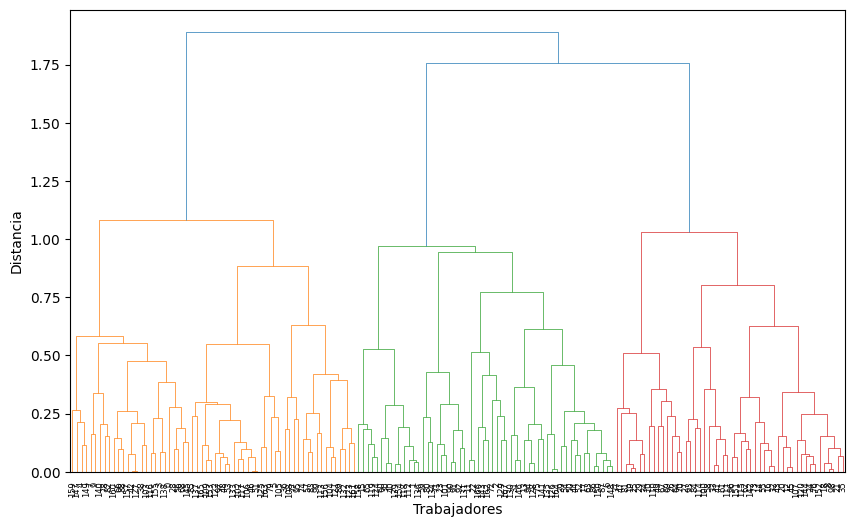

In [30]:
# Dendrograma (k grupos)
altura_corte = (ag_jer[-k, 2] + ag_jer[-(k - 1), 2]) / 2

fig, ax = plt.subplots(figsize=(10, 6))

dendrogram(
    ag_jer,
    labels=datos.index.astype(str),
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=altura_corte,
    ax=ax
)

for linea in ax.collections:
    linea.set_linewidth(0.5)

ax.set_title("")
ax.set_xlabel("Trabajadores")
ax.set_ylabel("Distancia")

plt.show()

## Validación

In [31]:
# Validación

# Silhouette promedio
np.fill_diagonal(D, 0)

val = silhouette_score(D, grupos, metric="precomputed")

val # Silhouette promedio

np.float64(0.19312787224400316)

In [32]:
# Dunn
clusters = np.unique(grupos)

diametros = []
separaciones = []

for g in clusters:
    idx = grupos == g
    diametros.append(D[np.ix_(idx, idx)].max())

for i, g1 in enumerate(clusters):
    for g2 in clusters[(i + 1):]:
        idx1 = grupos == g1
        idx2 = grupos == g2
        separaciones.append(D[np.ix_(idx1, idx2)].min())

val = min(separaciones) / max(diametros)

val # Dunn

np.float64(0.16432116981796704)

In [33]:
# Connectivity
neighbSize = 10

D_aux = D.copy()
np.fill_diagonal(D_aux, np.inf)

vecinos = np.argsort(D_aux, axis=1)[:, :neighbSize]

val = 0

for i in range(D_aux.shape[0]):
    for j in range(neighbSize):
        if grupos[i] != grupos[vecinos[i, j]]:
            val += 1 / (j + 1)

val # Connectivity

48.449603174603276

In [35]:
# Bootstrap Jaccard stability
np.random.seed(123)

B = 100
grupos_array = np.asarray(grupos)
clusters_original = np.unique(grupos_array)

original_clusters = {
    g: set(np.where(grupos_array == g)[0])
    for g in clusters_original
}

boot_jaccard = {
    g: []
    for g in clusters_original
}

for b in range(B):
    idx_boot = np.random.choice(np.arange(datos.shape[0]), size=datos.shape[0], replace=True)

    X_boot = datos.iloc[idx_boot].copy()

    X_boot["Ayuda"] = np.where(X_boot["Ayuda"] == "Sí", 1, 0) # binarias deben ser 0,1

    numeric_vars = X_boot.columns[[1, 3, 6, 8, 9, 12]].tolist()
    asymm_vars = X_boot.columns[[7]].tolist()
    factor_vars = X_boot.columns[[0, 2, 11]].tolist()
    ordered_vars = X_boot.columns[[4, 5, 10]].tolist()

    X_boot[factor_vars] = X_boot[factor_vars].astype("category")

    X_boot[ordered_vars[0]] = pd.Categorical(
        X_boot[ordered_vars[0]],
        categories=["Técnico", "Pregrado", "Posgrado"],
        ordered=True
    )

    X_boot[ordered_vars[1]] = X_boot[ordered_vars[1]].astype("string").str.strip().replace({
        "1.0": "1",
        "2.0": "2",
        "3.0": "3"
    })

    X_boot[ordered_vars[1]] = pd.Categorical(
        X_boot[ordered_vars[1]],
        categories=["1", "2", "3", "4+"],
        ordered=True
    )

    X_boot[ordered_vars[2]] = pd.Categorical(
        X_boot[ordered_vars[2]],
        categories=["Difícil", "Regular", "Buena"],
        ordered=True
    )

    partes = []
    pesos = []

    A = X_boot[numeric_vars].astype(float)
    A = (A - A.min()) / (A.max() - A.min())
    A = A.to_numpy()

    partes.append(np.abs(A[:, None, :] - A[None, :, :]))
    pesos.append(np.ones_like(partes[-1]))

    A = X_boot[factor_vars].astype(str).to_numpy()

    partes.append((A[:, None, :] != A[None, :, :]).astype(float))
    pesos.append(np.ones_like(partes[-1]))

    X_ord = pd.DataFrame(index=X_boot.index)

    X_ord[ordered_vars[0]] = X_boot[ordered_vars[0]].cat.codes / 2
    X_ord[ordered_vars[1]] = X_boot[ordered_vars[1]].cat.codes / 3
    X_ord[ordered_vars[2]] = X_boot[ordered_vars[2]].cat.codes / 2

    A = X_ord.to_numpy()

    partes.append(np.abs(A[:, None, :] - A[None, :, :]))
    pesos.append(np.ones_like(partes[-1]))

    A = X_boot[asymm_vars].to_numpy()

    dist_asymm = (A[:, None, :] != A[None, :, :]).astype(float)
    peso_asymm = ~((A[:, None, :] == 0) & (A[None, :, :] == 0))

    partes.append(dist_asymm)
    pesos.append(peso_asymm.astype(float))

    num = np.concatenate(partes, axis=2)
    w = np.concatenate(pesos, axis=2)

    D_boot = (num * w).sum(axis=2) / w.sum(axis=2)
    np.fill_diagonal(D_boot, 0)

    D_boot_cond = D_boot[np.triu_indices(D_boot.shape[0], k=1)]

    ag_boot = linkage(D_boot_cond, method="ward")
    grupos_boot = fcluster(ag_boot, t=k, criterion="maxclust")

    for g in clusters_original:
        original = original_clusters[g]
        jaccards = []

        for gb in np.unique(grupos_boot):
            boot_cluster = set(idx_boot[grupos_boot == gb])

            interseccion = len(original.intersection(boot_cluster))
            union = len(original.union(boot_cluster))

            jaccards.append(interseccion / union)

        boot_jaccard[g].append(max(jaccards))

bootmean = pd.Series(
    {
        g: np.mean(boot_jaccard[g])
        for g in clusters_original
    },
    name="Bootstrap Jaccard stability"
)

bootmean
bootmean.mean()

# Davies–Bouldin no aplica
# Gap no aplica
# APN no aplica
# FOM no aplica
# Prediction Strength no aplica

np.float64(0.46422866032182813)

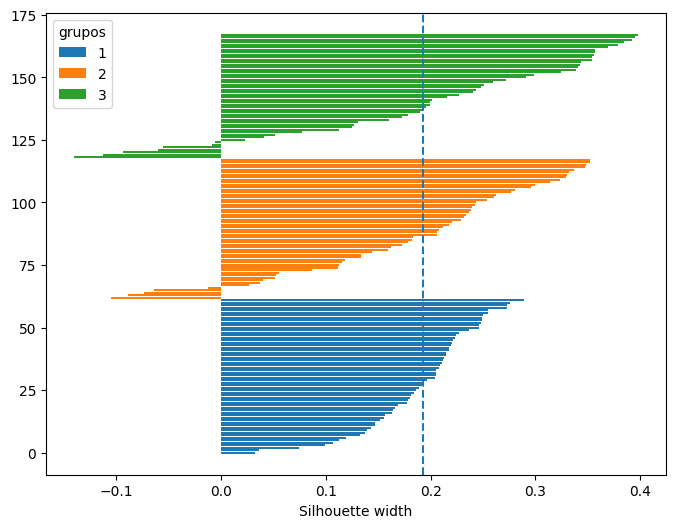

In [36]:
from sklearn.metrics import silhouette_samples

# Gráfica

# Silhouette
sil = silhouette_samples(D, grupos, metric="precomputed")

sil_df = pd.DataFrame({
    "sil_width": sil,
    "grupos": grupos
})

sil_df = sil_df.sort_values(["grupos", "sil_width"]).reset_index(drop=True)

plt.figure(figsize=(8, 6))

y_lower = 0

for g in sorted(sil_df["grupos"].unique()):
    vals = sil_df.loc[sil_df["grupos"] == g, "sil_width"].to_numpy()
    y_upper = y_lower + len(vals)

    plt.barh(
        range(y_lower, y_upper),
        vals,
        edgecolor="none",
        label=str(g)
    )

    y_lower = y_upper

plt.axvline(sil.mean(), linestyle="--")
plt.xlabel("Silhouette width")
plt.ylabel("")
plt.legend(title="grupos")
plt.show()